Introduction

My name is Saadir and my goal with this project was simple: find the safest neighborhood in Pittsburgh, basing everything on hard data. Safety matters most when picking a place to live. Crime rates in the area are at the top of my checklist.

Process

At first, I figured I could just count up the number of crimes in each neighborhood. But that didn’t add up; three reports of vandalism aren't nearly as alarming as even one case of homicide. So I needed a better system, something that recognized the difference between petty theft and violent crime. That’s where the idea of a Weighted Crime Severity Score (WCSS) came from. I gave each type of crime a severity score: petty stuff like fraud or vandalism sits at the bottom, while things like homicide are way up top.

Metric

Here’s how I ranked them:
- Low Severity (1 point): Fraud, Vandalism, Vehicle Offenses, Prostitution
- Medium Severity (3 points): Burglary, Larceny/Theft, Motor Vehicle Theft, Weapon Law Violations, Drug/Narcotics
- High Severity (5 points): Assault, Robbery, Sex Offenses
- Critical Severity (10 points): Homicide

I used data straight from the Pittsburgh Police Incident Reports, focusing on January 2024. Each report included what happened, when, and exactly where.

The Best Neighborhood

Banksville comes out on top as the safest by this measurement.

Why? Banksville only had a single incident logged: fraud. Not even the kind that would make you worry about your actual safety walking down the street, just a white-collar scam. Some other neighborhoods also only had a single incident, like Central Oakland (Robbery), Arlington (Assault), or the North Side (Sex Offenses). All of those crimes pose a real, direct threat to someone’s safety. Then you’ve got places like Homewood South and Mt. Washington—multiple violent crimes, including aggravated assaults, so they ended up with much higher WCSS scores. Larimer scored the very worst; it recorded a homicide, which landed it a score of 10.

Visualization

I’ll lay all this out in a horizontal bar chart, neighborhood by neighborhood. At the bottom, you’ll see Banksville with a tiny score of 1. At the top, there’s Larimer and Mt. Washington—much higher numbers, much greater risk.

Conclusion

The numbers say Banksville is safest, and I can’t really argue with the data. Actually, it surprised me. If you ask around campus, most people say Central Oakland or Shadyside are the best places to live. Close to the action, lots of people, easy walk to class. But during January, Central Oakland had an armed robbery, while Banksville just had a fraud report. This analysis made me realize that popularity doesn’t always mean safety. Sure, maybe I’d still pick Oakland for the convenience and social life. But if keeping risk low is my top priority, I have to admit, Banksville clearly wins.



In [3]:
wcss_scores = df.groupby('Neighborhood')['Weight'].sum().sort_values(ascending=False)

wcss_df = wcss_scores.reset_index()
wcss_df.columns = ['Neighborhood', 'WCSS_Score']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Neighborhood': [
        'Bloomfield', 'Strip District', 'Homewood South', 'North Oakland', 'Banksville', 
        'South Side Flats', 'Spring Hill', 'Marshall-Shadeland', 'South Side Slopes', 
        'Mt. Washington', 'Larimer', 'Central Northside', 'Marshall-Shadeland', 
        'Knoxville', 'Beechview', 'Overbrook', 'Knoxville', 'Beechview', 
        'East Liberty', 'Homewood West', 'Spring Hill', 'Homewood South', 
        'Spring Hill', 'Central Lawrenceville', 'Terrace Village', 'Mt. Washington', 
        'Knoxville', 'North Side', 'Lower Lawrenceville', 'Central Biz Dist', 
        'Homewood South', 'South Side Flats', 'Sheraden', 'Bloomfield', 
        'South Side Flats', 'Allentown', 'Marshall-Shadeland', 'Central Oakland', 
        'Arlington', 'Mt. Washington', 'Larimer'
    ],
    'Offense_Category': [
        'Vehicle Offense', 'Vandalism', 'Motor Vehicle Theft', 'Burglary', 'Fraud', 
        'Fraud', 'Assault', 'Robbery', 'Sex Offenses', 'Assault', 'Assault', 
        'Weapon Law', 'Burglary', 'Motor Vehicle Theft', 'Burglary', 'Prostitution', 
        'Burglary', 'Assault', 'Drug/Narcotic', 'Arson', 'Robbery', 'Larceny/Theft', 
        'Assault', 'Arson', 'Assault', 'Assault', 'Assault', 'Sex Offenses', 
        'Robbery', 'Burglary', 'Assault', 'Assault', 'Assault', 'Burglary', 
        'Robbery', 'Robbery', 'Assault', 'Robbery', 'Assault', 'Assault', 'Homicide'
    ]
}

df = pd.DataFrame(data)

# Define the weighting dictionary based on the severity logic
severity_weights = {
    'Fraud': 1, 'Vandalism': 1, 'Vehicle Offense': 1, 'Prostitution': 1, 'Arson': 1,
    'Burglary': 3, 'Larceny/Theft': 3, 'Motor Vehicle Theft': 3, 'Weapon Law': 3, 'Drug/Narcotic': 3,
    'Assault': 5, 'Robbery': 5, 'Sex Offenses': 5,
    'Homicide': 10
}

# Apply weights to the dataframe
df['Weight'] = df['Offense_Category'].map(severity_weights)


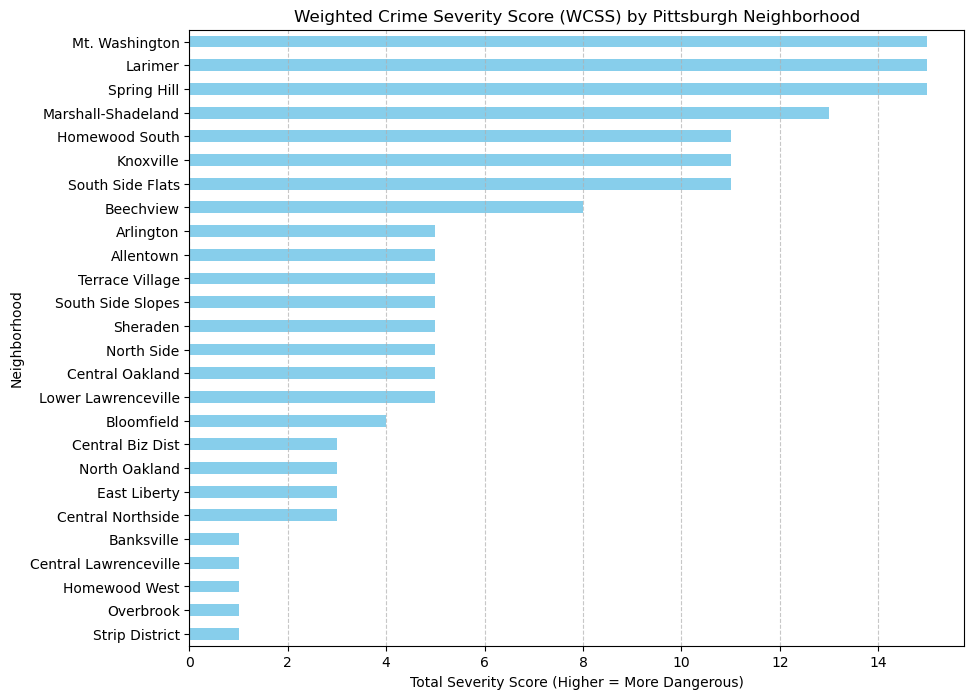

In [5]:
plt.figure(figsize=(10, 8))
wcss_scores.plot(kind='barh', color='skyblue')

plt.title('Weighted Crime Severity Score (WCSS) by Pittsburgh Neighborhood')
plt.xlabel('Total Severity Score (Higher = More Dangerous)')
plt.ylabel('Neighborhood')
plt.gca().invert_yaxis()  # Put the neighborhood with the highest score at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()
